# U-Net++ with EfficientNet-B3 Encoder

## Install dependencies

In [1]:
!pip install -q transformers albumentations optuna timm evaluate datasets accelerate
!pip install -q scikit-learn seaborn
!pip install -q segmentation-models-pytorch
!pip install opencv-python matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 14.7 MB/s eta 0:00:00


## Mount google drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Loading dataset to local Colab disk

In [8]:
import shutil, os, time

local = '/content/CSE465/RRSIS-D'
drive = '/content/drive/MyDrive/CSE465/RRSIS-D'

# Remove stale incomplete copy
if os.path.exists(local):
    print('Removing stale local copy...')
    shutil.rmtree(local)

# Fresh copy from Drive (this will take a while - 17k+ files)
t0 = time.time()
print('Copying from Drive (be patient, ~5-15 min for 17k files)...')
shutil.copytree(drive, local)
print(f'Copy done in {(time.time()-t0)/60:.1f} min')

# Verify
print('\nContents:')
for item in sorted(os.listdir(local)):
    full = os.path.join(local, item)
    if os.path.isdir(full):
        print(f'  DIR  {item}: {len(os.listdir(full))} items')
    else:
        print(f'  FILE {item}')

Removing stale local copy...
Copying from Drive (be patient, ~5-15 min for 17k files)...
Copy done in 9.6 min

Contents:
  DIR  JPEGImages: 17404 items
  DIR  ann_split: 17402 items
  FILE instances.json
  FILE refs(unc).p


## Defining data paths

In [9]:
IMAGE_DIR  = '/content/CSE465/RRSIS-D/JPEGImages'
LABEL_DIR  = '/content/CSE465/RRSIS-D/ann_split'
OUTPUT_DIR = '/content/drive/MyDrive/CSE465/checkpoints'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Image  dir:", IMAGE_DIR)
print("Label  dir:", LABEL_DIR)
print("Output dir:", OUTPUT_DIR)
print("Label dir exists?", os.path.exists(LABEL_DIR))
print("Image dir exists?", os.path.exists(IMAGE_DIR))

Image  dir: /content/CSE465/RRSIS-D/JPEGImages
Label  dir: /content/CSE465/RRSIS-D/ann_split
Output dir: /content/drive/MyDrive/CSE465/checkpoints
Label dir exists? True
Image dir exists? True


## Import necessary libraries

In [10]:
import os, glob, json, random, time, xml.etree.ElementTree as ET
from pathlib import Path
import xml.etree.ElementTree as ET
from collections import Counter

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
# Use new torch.amp API to silence deprecation warnings
from torch.amp import GradScaler, autocast

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    accuracy_score, confusion_matrix, classification_report
)

import segmentation_models_pytorch as smp

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU   : NVIDIA L4
VRAM  : 23.7 GB


## Parse Classes from XML

In [11]:
images_path = Path(IMAGE_DIR)
labels_path = Path(LABEL_DIR)

xml_files = list(labels_path.rglob("*.xml"))
print("Total XML files:", len(xml_files))

class_names_set = set()
box_counts = Counter()

for xf in xml_files:
    tree = ET.parse(xf)
    root = tree.getroot()

    for obj in root.findall("object"):
        class_name = obj.find("name").text.strip()

        class_names_set.add(class_name)
        box_counts[class_name] += 1

Total XML files: 17402


## Convert to Ordered Class List

In [12]:
class_names = sorted(list(class_names_set))
num_classes = len(class_names)

# Map class name → ID
class_to_id = {name: i for i, name in enumerate(class_names)}

print("Number of classes:", num_classes)
print("All classes:", class_names[:])

## Convert Counts to Array
counts = np.zeros(num_classes, dtype=int)

for class_name, count in box_counts.items():
    class_id = class_to_id[class_name]
    counts[class_id] = count

Number of classes: 20
All classes: ['Expressway-Service-area', 'Expressway-toll-station', 'airplane', 'airport', 'baseballfield', 'basketballcourt', 'bridge', 'chimney', 'dam', 'golffield', 'groundtrackfield', 'harbor', 'overpass', 'ship', 'stadium', 'storagetank', 'tenniscourt', 'trainstation', 'vehicle', 'windmill']


## Imbalance Metrics

In [13]:
total_boxes = counts.sum()
nonzero = counts[counts > 0]

max_boxes = int(nonzero.max()) if len(nonzero) else 0
min_boxes = int(nonzero.min()) if len(nonzero) else 0
imbalance_ratio = (max_boxes / min_boxes) if min_boxes > 0 else float("inf")

percent_share = (counts / total_boxes * 100) if total_boxes > 0 else np.zeros(num_classes)

print("Total objects:", total_boxes)
print("Max:", max_boxes)
print("Min:", min_boxes)
print("Imbalance ratio:", round(imbalance_ratio, 2), "x")

Total objects: 38320
Max: 7098
Min: 583
Imbalance ratio: 12.17 x


## Print Table

In [14]:
print("\nClass-wise distribution:")
print("-" * 70)
print(f"{'ID':>3} {'Class Name':25s} {'Count':>8} {'Share (%)':>10}")
print("-" * 70)

for i in range(num_classes):
    print(
        f"{i:3d} "
        f"{class_names[i]:25s} "
        f"{counts[i]:8d} "
        f"{percent_share[i]:10.2f}"
    )


Class-wise distribution:
----------------------------------------------------------------------
 ID Class Name                   Count  Share (%)
----------------------------------------------------------------------
  0 Expressway-Service-area       1417       3.70
  1 Expressway-toll-station       1102       2.88
  2 airplane                      1688       4.41
  3 airport                       1241       3.24
  4 baseballfield                 3658       9.55
  5 basketballcourt               1287       3.36
  6 bridge                        2486       6.49
  7 chimney                       1243       3.24
  8 dam                           1037       2.71
  9 golffield                     1032       2.69
 10 groundtrackfield              2455       6.41
 11 harbor                         583       1.52
 12 overpass                      2234       5.83
 13 ship                          1960       5.11
 14 stadium                       1138       2.97
 15 storagetank                 

## Imbalance visualization

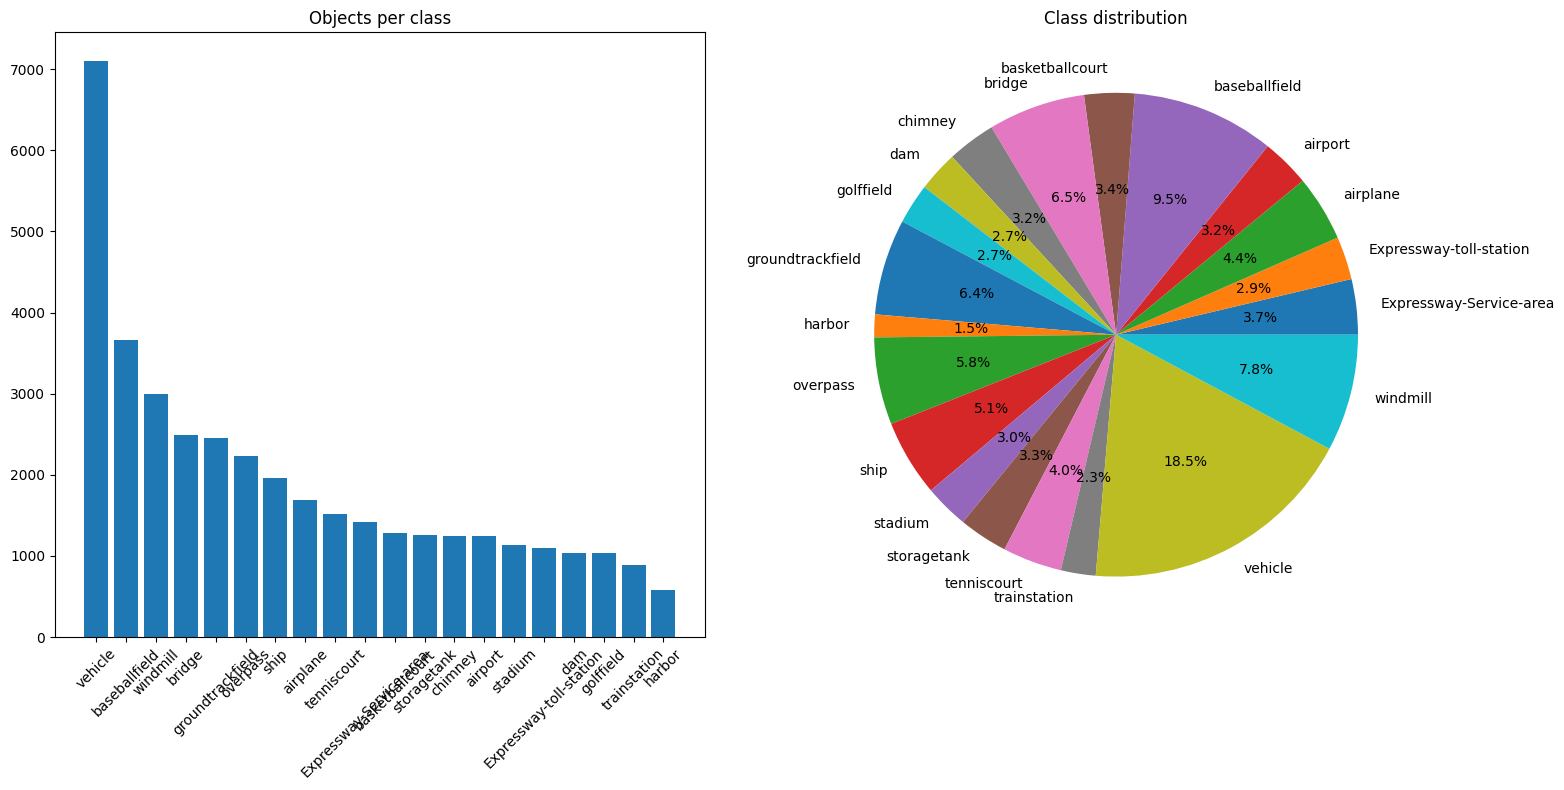

In [15]:
import matplotlib.pyplot as plt

idx = np.argsort(-counts)
labels_sorted = [class_names[i] for i in idx]
counts_sorted = counts[idx]

min_pct_to_show = 1.0

big_idx = np.where(percent_share >= min_pct_to_show)[0]
small_idx = np.where(percent_share < min_pct_to_show)[0]

pie_labels = [class_names[i] for i in big_idx]
pie_sizes = percent_share[big_idx].tolist()

other_pct = float(percent_share[small_idx].sum())
if other_pct > 0:
    pie_labels.append("Other")
    pie_sizes.append(other_pct)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].bar(labels_sorted, counts_sorted)
axes[0].set_title("Objects per class")
axes[0].tick_params(axis="x", rotation=45)

axes[1].pie(pie_sizes, labels=pie_labels, autopct="%1.1f%%")
axes[1].set_title("Class distribution")

plt.tight_layout()
plt.show()

## Class Definitions & Label Mapping

In [16]:
CLASSES = [
    'Expressway-Service-area', 'Expressway-toll-station', 'airplane',
    'airport', 'baseballfield', 'basketballcourt', 'bridge', 'chimney',
    'dam', 'golffield', 'groundtrackfield', 'harbor', 'overpass', 'ship',
    'stadium', 'storagetank', 'tenniscourt', 'trainstation', 'vehicle',
    'windmill'
]

# Background (0) + 20 object classes → 21 total labels
ALL_LABELS = ['background'] + CLASSES
NUM_LABELS = len(ALL_LABELS)   # 21

label2id = {name: idx for idx, name in enumerate(ALL_LABELS)}
id2label = {idx: name for idx, name in enumerate(ALL_LABELS)}

# Object-class counts from dataset analysis (indices 0–19 = CLASSES[0–19])
CLASS_COUNTS = [
    1417, 1102, 1688, 1241, 3658, 1287, 2486, 1243,
    1037, 1032, 2455,  583, 2234, 1960, 1138, 1255,
    1519,  891, 7098, 2996
]

print(f'Total labels (incl. background): {NUM_LABELS}')

Total labels (incl. background): 21


## Class Imbalance — Inverse-Frequency Loss Weights

In [17]:
def compute_class_weights(counts, bg_weight=1.0):
    """
    Inverse-frequency class weights.
    bg_weight=1.0 keeps background on equal footing (do NOT use 0.1 - it causes
    the model to actively avoid predicting background, which is ~95% of pixels).
    """
    arr   = np.array(counts, dtype=np.float64)
    total = arr.sum()
    n     = len(arr)
    w     = total / (n * arr)
    w     = w / w.mean()
    w     = np.concatenate([[bg_weight], w])
    return torch.tensor(w, dtype=torch.float32)


CLASS_WEIGHTS = compute_class_weights(CLASS_COUNTS, bg_weight=1.0)

print('Top-5 highest weights (rarest classes):')
pairs = sorted(zip(ALL_LABELS, CLASS_WEIGHTS.tolist()), key=lambda x: -x[1])
for name, w in pairs[:6]:
    print(f'  {name:<32s}  {w:.4f}')
print(f'Background weight: {CLASS_WEIGHTS[0].item():.4f}')

Top-5 highest weights (rarest classes):
  harbor                            2.4136
  trainstation                      1.5793
  golffield                         1.3635
  dam                               1.3569
  Expressway-toll-station           1.2769
  stadium                           1.2365
Background weight: 1.0000


## Annotation Parser to Segmentation Mask

In [18]:
def parse_xml_to_mask(xml_path: str, img_h: int, img_w: int) -> np.ndarray:
    """
    Parse a PASCAL-VOC XML and return a uint8 segmentation mask.
    Pixel value = label index (0 = background).
    Objects are painted large-first so small objects sit on top.
    """
    mask = np.zeros((img_h, img_w), dtype=np.uint8)
    tree = ET.parse(xml_path)
    root = tree.getroot()

    objects = []
    for obj in root.findall('object'):
        name = obj.find('name').text.strip()
        if name not in label2id:
            continue
        bb   = obj.find('bndbox')
        xmin = max(0,     int(float(bb.find('xmin').text)))
        ymin = max(0,     int(float(bb.find('ymin').text)))
        xmax = min(img_w, int(float(bb.find('xmax').text)))
        ymax = min(img_h, int(float(bb.find('ymax').text)))
        area = (xmax - xmin) * (ymax - ymin)
        objects.append((area, xmin, ymin, xmax, ymax, label2id[name]))

    # Sort descending by area — paint large boxes first
    objects.sort(reverse=True, key=lambda x: x[0])
    for _, xmin, ymin, xmax, ymax, cls_idx in objects:
        mask[ymin:ymax, xmin:xmax] = cls_idx

    return mask


# Quick sanity check
sample_xmls = sorted(glob.glob(os.path.join(LABEL_DIR, '**', '*.xml'), recursive=True))
print(f'Found {len(sample_xmls)} XML files')

if sample_xmls:
    sx       = sample_xmls[0]
    img_name = Path(sx).stem + '.jpg'
    img_path = os.path.join(IMAGE_DIR, img_name)
    if os.path.exists(img_path):
        _img = cv2.imread(img_path)
        _h, _w = _img.shape[:2]
        _mask  = parse_xml_to_mask(sx, _h, _w)
        unique = np.unique(_mask)
        print(f'Sample : {img_name}  size={_w}x{_h}')
        print(f'Classes: {[id2label[u] for u in unique]}')

Found 17402 XML files
Sample : 00001.jpg  size=800x800
Classes: ['background', 'golffield']


## Train-Val-Test Split

In [19]:
def build_file_pairs(image_dir, label_dir):
    """
    Return list of (img_path, xml_path) tuples for matched files.
    Tries multiple image extensions because some datasets mix .jpg/.JPG/.png/.tif.
    """
    xml_paths = sorted(glob.glob(os.path.join(label_dir, '**', '*.xml'), recursive=True))
    candidate_exts = ['.jpg', '.jpeg', '.png', '.tif', '.tiff', '.JPG', '.JPEG', '.PNG']
    pairs = []
    missing = 0
    for xp in xml_paths:
        stem  = Path(xp).stem
        found = None
        for ext in candidate_exts:
            cand = os.path.join(image_dir, stem + ext)
            if os.path.exists(cand):
                found = cand
                break
        if found is not None:
            pairs.append((found, xp))
        else:
            missing += 1
    if missing:
        print(f'WARNING: {missing} XML files had no matching image (will be skipped).')
    return pairs


all_pairs = build_file_pairs(IMAGE_DIR, LABEL_DIR)
print(f'Valid (image, xml) pairs: {len(all_pairs)}')

# 70 / 15 / 15 random split
random.shuffle(all_pairs)
n      = len(all_pairs)
n_val  = int(n * 0.15)
n_test = int(n * 0.15)

test_pairs  = all_pairs[:n_test]
val_pairs   = all_pairs[n_test : n_test + n_val]
train_pairs = all_pairs[n_test + n_val :]

print(f'Train: {len(train_pairs)}  Val: {len(val_pairs)}  Test: {len(test_pairs)}')

Valid (image, xml) pairs: 17402
Train: 12182  Val: 2610  Test: 2610


## Data Augmentation

In [20]:
IMG_SIZE = 480

# Training transforms
train_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),

    # Spatial augmentations — applied identically to image AND mask
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomResizedCrop(
        size=(IMG_SIZE, IMG_SIZE), scale=(0.6, 1.0), ratio=(0.8, 1.2), p=0.4
    ),
    A.Perspective(scale=(0.02, 0.06), p=0.3),
    A.GridDistortion(num_steps=5, distort_limit=0.15, p=0.2),

    # Pixel-level augmentations — image only
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.6),
    A.CLAHE(clip_limit=4.0, p=0.3),               # local contrast enhancement
    A.HueSaturationValue(hue_shift_limit=10,
                         sat_shift_limit=20,
                         val_shift_limit=20, p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.Sharpen(alpha=(0.1, 0.4), lightness=(0.8, 1.2), p=0.2),
    A.RandomShadow(shadow_roi=(0, 0, 1, 1),        # simulates cloud shadow
                   num_shadows_limit=(1, 2),
                   shadow_dimension=5, p=0.2),
    A.GaussNoise(std_range=(0.01, 0.05), p=0.2),
    A.CoarseDropout(                               # forces partial-view robustness
        num_holes_range=(1, 4),
        hole_height_range=(0.05, 0.15),
        hole_width_range=(0.05, 0.15),
        p=0.3
    ),

    # Normalise with ImageNet stats, then convert to tensor
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# Validation / Test transforms (no augmentation)
val_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

print(f'Image size : {IMG_SIZE}×{IMG_SIZE}')
print('Transforms ready.')

Image size : 256×256
Transforms ready.


## Dataset Class

In [21]:
class RRSISDataset(Dataset):
    """
    RRSIS-D PyTorch Dataset.
    __getitem__ returns:
      pixel_values : FloatTensor (3, H, W)  — normalised image
      labels       : LongTensor  (H, W)     — segmentation mask (0=bg)
    """

    def __init__(self, pairs, transforms=None):
        self.pairs      = pairs
        self.transforms = transforms

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, xml_path = self.pairs[idx]

        # Load image (BGR → RGB)
        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(f'Image not found: {img_path}')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        # Build segmentation mask from XML
        mask = parse_xml_to_mask(xml_path, h, w)

        # Apply augmentations
        if self.transforms:
            out  = self.transforms(image=img, mask=mask)
            img  = out['image']   # Tensor (3, H, W)
            mask = out['mask']    # Tensor (H, W)

        if not isinstance(mask, torch.Tensor):
            mask = torch.from_numpy(mask)
        mask = mask.long()

        return {'pixel_values': img, 'labels': mask}

    def get_dominant_class(self, idx):
        """Most frequent foreground class index (for WeightedRandomSampler)."""
        img_path, xml_path = self.pairs[idx]
        img = cv2.imread(img_path)
        h, w = img.shape[:2]
        mask = parse_xml_to_mask(xml_path, h, w)
        fg   = mask[mask > 0]
        if len(fg) == 0:
            return 0
        return int(Counter(fg.tolist()).most_common(1)[0][0])


train_ds = RRSISDataset(train_pairs, transforms=train_transforms)
val_ds   = RRSISDataset(val_pairs,   transforms=val_transforms)
test_ds  = RRSISDataset(test_pairs,  transforms=val_transforms)

print(f'Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}')

Train: 12182  Val: 2610  Test: 2610


## WeightedRandomSampler

In [ ]:
SAMPLER_CACHE = os.path.join(OUTPUT_DIR, 'train_dominant_classes.npy')

if os.path.exists(SAMPLER_CACHE):
    dominant_classes = np.load(SAMPLER_CACHE)
    print(f'Loaded dominant-class cache ({len(dominant_classes)} entries).')
else:
    print('Computing dominant classes (runs once, then cached)...')
    dominant_classes = np.array(
        [train_ds.get_dominant_class(i) for i in range(len(train_ds))],
        dtype=np.int64
    )
    np.save(SAMPLER_CACHE, dominant_classes)
    print('Saved to cache.')

class_freq = np.bincount(dominant_classes, minlength=NUM_LABELS)
class_freq = np.where(class_freq == 0, 1, class_freq)
sample_weights = torch.tensor(
    [1.0 / class_freq[c] for c in dominant_classes], dtype=torch.float32
)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

## DataLoaders

In [38]:
BATCH_SIZE  = 8
NUM_WORKERS = 2

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print(f'Train batches: {len(train_loader)}')

Train batches: 1522


## Build U-Net++ with EfficientNet-B3 Encoder (replaces SegFormer & DeepLabV3)

In [39]:
ENCODER_NAME    = 'efficientnet-b3'
ENCODER_WEIGHTS = 'imagenet'

def build_model(num_classes):
    """
    Build U-Net++ with EfficientNet-B3 encoder.
    Wrapped so output mimics {'out': logits} dict used by training loop.
    """
    base = smp.UnetPlusPlus(
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=3,
        classes=num_classes,
        activation=None,
    )

    class SMPWrapper(nn.Module):
        def __init__(self, net):
            super().__init__()
            self.net = net
            self.backbone = net.encoder  # expose for freeze code

        def forward(self, x):
            return {'out': self.net(x)}

    return SMPWrapper(base)


model = build_model(NUM_LABELS).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Architecture          : U-Net++ / {ENCODER_NAME}')
print(f'Total parameters      : {total_params:,}')
print(f'Trainable parameters  : {trainable_params:,}')
print(f'Non-trainable params  : {total_params - trainable_params:,}')

Architecture          : U-Net++ / efficientnet-b3
Total parameters      : 13,627,693
Trainable parameters  : 13,627,693
Non-trainable params  : 0


In [40]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params (full model): {trainable_params:,}')

Trainable params (full model): 13,627,693


## Model Size on Disk

In [41]:
import tempfile

def get_model_size_mb(model):
    """Save model state_dict to a temp file and return its size in MB."""
    with tempfile.NamedTemporaryFile(suffix='.pt', delete=False) as tmp:
        torch.save(model.state_dict(), tmp.name)
        size_mb = os.path.getsize(tmp.name) / (1024 ** 2)
    os.unlink(tmp.name)   # clean up
    return size_mb


model_size_mb = get_model_size_mb(model)
print(f'Model size on disk    : {model_size_mb:.1f} MB')
print(f'Total parameters      : {total_params:,}')
print(f'Trainable parameters  : {trainable_params:,}')

Model size on disk    : 52.7 MB
Total parameters      : 13,627,693
Trainable parameters  : 13,627,693


## Loss Function: Weighted Focal + Dice

In [42]:
class FocalLoss(nn.Module):
    """Multi-class alpha-weighted focal loss. ignore_index=-100 skips padded pixels."""
    def __init__(self, alpha=None, gamma=2.0, ignore_index=-100):
        super().__init__()
        self.alpha        = alpha
        self.gamma        = gamma
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        alpha = self.alpha.to(logits.device) if self.alpha is not None else None
        ce    = F.cross_entropy(
            logits, targets,
            weight=alpha,
            ignore_index=self.ignore_index,
            reduction='none'
        )  # (B, H, W)
        with torch.no_grad():
            pt = torch.exp(-ce)
        focal = (1 - pt) ** self.gamma * ce
        valid = (targets != self.ignore_index)
        return focal[valid].mean()


class DiceLoss(nn.Module):
    """Soft multi-class Dice loss. smooth=1 prevents division by zero."""
    def __init__(self, smooth=1.0, ignore_index=-100):
        super().__init__()
        self.smooth       = smooth
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        B, C, H, W = logits.shape
        probs       = logits.softmax(dim=1)
        valid_mask  = (targets != self.ignore_index)
        targets_c   = targets.clone()
        targets_c[~valid_mask] = 0
        targets_oh  = F.one_hot(targets_c, C).permute(0, 3, 1, 2).float()
        valid_mask  = valid_mask.unsqueeze(1).float()
        probs       = probs * valid_mask
        targets_oh  = targets_oh * valid_mask
        inter       = (probs * targets_oh).sum(dim=(0, 2, 3))
        union       = probs.sum(dim=(0, 2, 3)) + targets_oh.sum(dim=(0, 2, 3))
        dice_cls    = (2 * inter + self.smooth) / (union + self.smooth)
        return 1.0 - dice_cls.mean()


class CombinedLoss(nn.Module):
    def __init__(self, class_weights, dice_weight=0.5, gamma=2.0):
        super().__init__()
        self.focal       = FocalLoss(alpha=class_weights, gamma=gamma)
        self.dice        = DiceLoss()
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        return self.focal(logits, targets) + self.dice_weight * self.dice(logits, targets)


uniform_weights = torch.ones(NUM_LABELS)
criterion = CombinedLoss(uniform_weights, dice_weight=0.5, gamma=2.0)
print('Loss: Weighted Focal + Dice ready.')

Loss: Weighted Focal + Dice ready.


## Comprehensive Metrics

In [43]:
class SegMetrics:
    """
    Accumulates predictions across batches and computes all metrics at once.

    Stores:
      - confusion matrix (for IoU, Dice, per-class stats)
      - flat arrays of preds + targets (for sklearn P/R/F1)
    """

    def __init__(self, num_classes, ignore_index=-100, max_pixels=5_000_000):
        """
        num_classes  : number of label classes
        ignore_index : label value to exclude from metrics
        max_pixels   : cap on flat arrays to avoid OOM (randomly sampled)
        """
        self.K            = num_classes
        self.ignore_index = ignore_index
        self.max_pixels   = max_pixels
        self.reset()

    def reset(self):
        self.cm      = torch.zeros(self.K, self.K, dtype=torch.int64)
        self._preds  = []
        self._labels = []

    @torch.no_grad()
    def update(self, logits, targets):
        """
        logits  : (B, C, H, W)  raw model output
        targets : (B, H, W)     ground truth label indices
        """
        # Upsample if SegFormer returned at 1/4 resolution
        if logits.shape[-2:] != targets.shape[-2:]:
            logits = F.interpolate(
                logits.float(), size=targets.shape[-2:],
                mode='bilinear', align_corners=False
            )
        preds   = logits.argmax(dim=1).cpu()   # (B, H, W)
        targets = targets.cpu()

        valid   = (targets != self.ignore_index)
        p_flat  = preds[valid].numpy().astype(np.int32)
        t_flat  = targets[valid].numpy().astype(np.int32)

        # Update confusion matrix
        combined = self.K * t_flat + p_flat
        counts   = np.bincount(combined, minlength=self.K ** 2)
        self.cm += torch.tensor(counts.reshape(self.K, self.K), dtype=torch.int64)

        # Store flat arrays (capped to avoid OOM)
        if len(self._preds) < self.max_pixels:
            self._preds.append(p_flat)
            self._labels.append(t_flat)

    def compute(self):
        """
        Returns dict with all metrics.
        """
        cm  = self.cm.float()
        tp  = torch.diag(cm)
        fp  = cm.sum(dim=0) - tp
        fn  = cm.sum(dim=1) - tp

        # ── IoU & Dice per class ──────────────────────────────
        iou_per  = tp / (tp + fp + fn + 1e-6)
        dice_per = 2 * tp / (2 * tp + fp + fn + 1e-6)
        present  = cm.sum(dim=1) > 0   # classes that appear in GT

        miou  = iou_per[present].mean().item()
        oiou  = (tp.sum() / (tp.sum() + fp.sum() + fn.sum() + 1e-6)).item()
        mdice = dice_per[present].mean().item()

        # ── Pixel accuracy ────────────────────────────────────
        pixel_acc = (tp.sum() / (cm.sum() + 1e-6)).item()

        # ── sklearn Precision / Recall / F1 ──────────────────
        # Flatten accumulated arrays
        if self._preds:
            all_preds  = np.concatenate(self._preds)
            all_labels = np.concatenate(self._labels)
            # Use zero_division=0 to silence warnings for absent classes
            precision  = precision_score(all_labels, all_preds,
                                         average='macro', zero_division=0)
            recall     = recall_score(all_labels, all_preds,
                                      average='macro', zero_division=0)
            f1         = f1_score(all_labels, all_preds,
                                  average='macro', zero_division=0)
        else:
            precision = recall = f1 = 0.0

        return {
            'pixel_acc'    : pixel_acc,
            'precision'    : precision,
            'recall'       : recall,
            'f1'           : f1,
            'mIoU'         : miou,
            'oIoU'         : oiou,
            'Dice'         : mdice,
            'iou_per_class': iou_per.tolist(),
        }

    def compute_confusion_matrix(self):
        """Return the raw NUM_LABELS×NUM_LABELS confusion matrix as numpy."""
        return self.cm.numpy()


print('SegMetrics class ready.')

SegMetrics class ready.


## Early Stopping

In [44]:
class EarlyStopping:
    """
    Monitors a metric (higher = better) and stops training if it
    fails to improve for `patience` consecutive epochs.

    Usage in training loop:
        es = EarlyStopping(patience=7, min_delta=0.001)
        if es.step(val_miou, model):
            print('Early stopping triggered!')
            break
        es.restore(model)   # load best weights after loop ends
    """

    def __init__(self, patience=7, min_delta=0.001, verbose=True):
        self.patience   = patience
        self.min_delta  = min_delta
        self.verbose    = verbose
        self.best_score = None
        self.counter    = 0
        self.best_state = None   # deepcopy of best model weights
        self.triggered  = False

    def step(self, score: float, model: nn.Module) -> bool:
        """
        Call after each validation epoch.
        Returns True if training should stop.
        """
        import copy
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter    = 0
            # Save a CPU copy of the best weights (no extra GPU memory)
            self.best_state = copy.deepcopy(
                {k: v.cpu() for k, v in model.state_dict().items()}
            )
            if self.verbose:
                print(f'  [EarlyStopping] New best: {score:.4f}  (patience counter reset)')
        else:
            self.counter += 1
            if self.verbose:
                print(f'  [EarlyStopping] No improvement. Counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.triggered = True
                return True
        return False

    def restore(self, model: nn.Module):
        """Load the best weights back into the model."""
        if self.best_state is not None:
            model.load_state_dict(
                {k: v.to(next(model.parameters()).device)
                 for k, v in self.best_state.items()}
            )
            print(f'  [EarlyStopping] Best weights restored (best mIoU={self.best_score:.4f})')


print('EarlyStopping class ready.')

EarlyStopping class ready.


## Hypreparameter tuning using Optuna

In [60]:
TUNE_EPOCHS = 3
TUNE_SUBSET = 500
N_TRIALS    = 15


def optuna_objective(trial):
    lr           = trial.suggest_float('lr',           1e-5, 5e-4, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    dice_weight  = trial.suggest_float('dice_weight',  0.1,  1.0)
    focal_gamma  = trial.suggest_float('focal_gamma',  0.5,  4.0)

    t_model = build_model(NUM_LABELS).to(DEVICE)

    for param in model.backbone.parameters():
        param.requires_grad = False

    bb_params   = [p for n, p in t_model.named_parameters() if 'decode_head' not in n]
    head_params = [p for n, p in t_model.named_parameters() if 'decode_head' in n]
    optimizer   = torch.optim.AdamW(
        [{'params': bb_params,   'lr': lr * 0.1},
         {'params': head_params, 'lr': lr}],
        weight_decay=weight_decay
    )

    indices  = np.random.choice(len(train_ds), TUNE_SUBSET, replace=False)
    t_loader = DataLoader(
        torch.utils.data.Subset(train_ds, indices),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True
    )
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=[lr * 0.1, lr],
        total_steps=len(t_loader) * TUNE_EPOCHS,
        pct_start=0.3,
    )
    t_crit  = CombinedLoss(CLASS_WEIGHTS, dice_weight=dice_weight, gamma=focal_gamma)
    scaler  = GradScaler()

    for _ in range(TUNE_EPOCHS):
        train_one_epoch(t_model, t_loader, t_crit, optimizer, scheduler, scaler, DEVICE)

    val_stats = evaluate(t_model, val_loader, t_crit, DEVICE)
    del t_model
    torch.cuda.empty_cache()
    return val_stats['mIoU']


study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=SEED),
    study_name='rrsisd_segformer'
)

print(f'Running {N_TRIALS} Optuna trials ({TUNE_EPOCHS} epochs each)...')
study.optimize(optuna_objective, n_trials=N_TRIALS, show_progress_bar=True)

best = study.best_params
print('\n=== Best Hyperparameters ===')
for k, v in best.items():
    print(f'  {k:<20s}: {v:.6f}')
print(f'  Best val mIoU  : {study.best_value:.4f}')

=== Best Hyperparameters ===
  lr                  : 0.000490
  weight_decay        : 0.000252
  dice_weight         : 0.574923
  focal_gamma         : 1.004319

  Best val mIoU       : 0.1212


## Train / Evaluate Functions

In [45]:
def train_one_epoch(model, loader, criterion, optimizer,
                    onecycle_scheduler, scaler, device):
    model.train()
    metrics    = SegMetrics(NUM_LABELS)
    total_loss = 0.0

    for batch in loader:
        imgs    = batch['pixel_values'].to(device, non_blocking=True)
        targets = batch['labels'].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast('cuda'):
            outputs = model(imgs)
            preds   = outputs['out']
            loss    = criterion(preds, targets)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        onecycle_scheduler.step()

        total_loss += loss.item()
        metrics.update(preds.detach(), targets)

    stats         = metrics.compute()
    stats['loss'] = total_loss / len(loader)
    return stats


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    metrics    = SegMetrics(NUM_LABELS)
    total_loss = 0.0

    for batch in loader:
        imgs    = batch['pixel_values'].to(device, non_blocking=True)
        targets = batch['labels'].to(device, non_blocking=True)

        with autocast('cuda'):
            outputs = model(imgs)
            preds   = outputs['out']
            loss    = criterion(preds, targets)

        total_loss += loss.item()
        metrics.update(preds, targets)

    stats         = metrics.compute()
    stats['loss'] = total_loss / len(loader)
    stats['_cm']  = metrics.compute_confusion_matrix()
    return stats


print('train_one_epoch() and evaluate() defined.')

train_one_epoch() and evaluate() defined.


## Full Training config

In [46]:
# Default hyperparameters (Optuna tuning removed)
LR           = 3e-4    # bumped from 6e-5 - safe for OneCycle with full unfrozen model
WEIGHT_DECAY = 1e-4
DICE_WEIGHT  = 0.5
FOCAL_GAMMA  = 2.0
NUM_EPOCHS   = 15      # bumped from 10 - still well within 2-hour budget
ES_PATIENCE  = 8

# Build fresh model — encoder will NOT be frozen this time
model = build_model(NUM_LABELS).to(DEVICE)

# Differential learning rates: encoder slow (pretrained), decoder fast (fresh head)
enc_params = [p for n, p in model.named_parameters() if 'backbone' in n or 'encoder' in n]
dec_params = [p for n, p in model.named_parameters() if 'backbone' not in n and 'encoder' not in n]

optimizer = torch.optim.AdamW(
    [{'params': enc_params, 'lr': LR * 0.1},
     {'params': dec_params, 'lr': LR}],
    weight_decay=WEIGHT_DECAY
)

total_steps   = len(train_loader) * NUM_EPOCHS
onecycle_sch  = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[LR * 0.1, LR],
    total_steps=total_steps,
    pct_start=0.1,
    div_factor=25,
    final_div_factor=1e4,
)

plateau_sch = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3,
    min_lr=1e-7
)

criterion      = CombinedLoss(CLASS_WEIGHTS, dice_weight=DICE_WEIGHT, gamma=FOCAL_GAMMA)
scaler         = GradScaler('cuda')
early_stop     = EarlyStopping(patience=ES_PATIENCE, min_delta=0.001, verbose=True)
best_ckpt_path = os.path.join(OUTPUT_DIR, 'best_model.pt')

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Config:')
print(f'  Architecture     : U-Net++ / {ENCODER_NAME}')
print(f'  IMG_SIZE         : {IMG_SIZE}x{IMG_SIZE}')
print(f'  Batch size       : {BATCH_SIZE}')
print(f'  Encoder LR       : {LR * 0.1:.2e}  (NOT frozen)')
print(f'  Decoder LR       : {LR:.2e}')
print(f'  Weight decay     : {WEIGHT_DECAY:.2e}')
print(f'  Dice weight      : {DICE_WEIGHT:.2f}')
print(f'  Focal gamma      : {FOCAL_GAMMA:.2f}')
print(f'  Background weight: {CLASS_WEIGHTS[0].item():.2f}')
print(f'  Max epochs       : {NUM_EPOCHS}')
print(f'  Early stopping   : patience={ES_PATIENCE}')
print(f'  Trainable params : {trainable_params:,}')

Config:
  Architecture     : U-Net++ / efficientnet-b3
  IMG_SIZE         : 256x256
  Batch size       : 8
  Encoder LR       : 3.00e-05  (NOT frozen)
  Decoder LR       : 3.00e-04
  Weight decay     : 1.00e-04
  Dice weight      : 0.50
  Focal gamma      : 2.00
  Background weight: 1.00
  Max epochs       : 15
  Early stopping   : patience=8
  Trainable params : 13,627,693


In [51]:
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'train_miou': [], 'val_miou': [],
    'train_f1':   [], 'val_f1':   [],
    'epoch_time': [],
    'lr_backbone': [], 'lr_head': []
}

scaler = GradScaler('cuda')

total_train_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    # ── Train ─────────────────────────────────────────────────
    train_stats = train_one_epoch(
        model, train_loader, criterion,
        optimizer, onecycle_sch, scaler, DEVICE
    )

    # ── Validate ──────────────────────────────────────────────
    val_stats = evaluate(model, val_loader, criterion, DEVICE)

    # ── ReduceLROnPlateau steps per epoch on val mIoU ─────────
    plateau_sch.step(val_stats['mIoU'])

    epoch_time = time.time() - epoch_start

    # ── Record history ────────────────────────────────────────
    history['train_loss'].append(train_stats['loss'])
    history['val_loss'].append(val_stats['loss'])
    history['train_acc'].append(train_stats['pixel_acc'])
    history['val_acc'].append(val_stats['pixel_acc'])
    history['train_miou'].append(train_stats['mIoU'])
    history['val_miou'].append(val_stats['mIoU'])
    history['train_f1'].append(train_stats['f1'])
    history['val_f1'].append(val_stats['f1'])
    history['epoch_time'].append(epoch_time)
    history['lr_backbone'].append(optimizer.param_groups[0]['lr'])
    history['lr_head'].append(optimizer.param_groups[1]['lr'])

    # ── Print epoch summary ────────────────────────────────────
    print(
        f'Epoch {epoch:3d}/{NUM_EPOCHS} | '
        f'loss {train_stats["loss"]:.4f}/{val_stats["loss"]:.4f} | '
        f'acc {train_stats["pixel_acc"]:.4f}/{val_stats["pixel_acc"]:.4f} | '
        f'mIoU {train_stats["mIoU"]:.4f}/{val_stats["mIoU"]:.4f} | '
        f'F1 {train_stats["f1"]:.4f}/{val_stats["f1"]:.4f} | '
        f'{epoch_time:.0f}s'
    )

    # ── Save best checkpoint ──────────────────────────────────
    if early_stop.best_score is None or val_stats['mIoU'] > early_stop.best_score:
        torch.save({
            'epoch':       epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_miou':    val_stats['mIoU'],
        }, best_ckpt_path)

    # ── Early stopping check ──────────────────────────────────
    if early_stop.step(val_stats['mIoU'], model):
        print(f'\nEarly stopping triggered at epoch {epoch}.')
        break
else:
    print(f'\nReached max epochs ({NUM_EPOCHS}). Early stopping triggered at final epoch.')

# Restore best weights after training ends
early_stop.restore(model)

total_train_time = time.time() - total_train_start
avg_epoch_time   = np.mean(history['epoch_time'])

print(f'\nTraining complete.')
print(f'  Total training time   : {total_train_time / 60:.1f} min')
print(f'  Average time / epoch  : {avg_epoch_time:.1f} s')
print(f'  Best val mIoU         : {early_stop.best_score:.4f}')

Train:   0%|          | 0/1522 [00:00<?, ?it/s]

Eval :   0%|          | 0/327 [00:00<?, ?it/s]

Epoch   1/15 | loss 0.7667/0.5840 | acc 0.8469/0.8884 | mIoU 0.1942/0.3644 | F1 0.2857/0.4831 | 576s
  [EarlyStopping] New best: 0.3644  (patience counter reset)


Train:   0%|          | 0/1522 [00:00<?, ?it/s]

Eval :   0%|          | 0/327 [00:00<?, ?it/s]

...

Train:   0%|          | 0/1522 [00:00<?, ?it/s]

Eval :   0%|          | 0/327 [00:00<?, ?it/s]

Epoch  14/15 | loss 0.4305/0.3961 | acc 0.9258/0.9431 | mIoU 0.5963/0.6355 | F1 0.7338/0.7651 | 580s
  [EarlyStopping] New best: 0.6355  (patience counter reset)


Train:   0%|          | 0/1522 [00:00<?, ?it/s]

ValueError: Tried to step 22831 times. The specified number of total steps is 22830

## Training Curves — Loss, Accuracy, mIoU, F1, LR

Saved to /content/drive/MyDrive/CSE465/checkpoints/training_curves.png


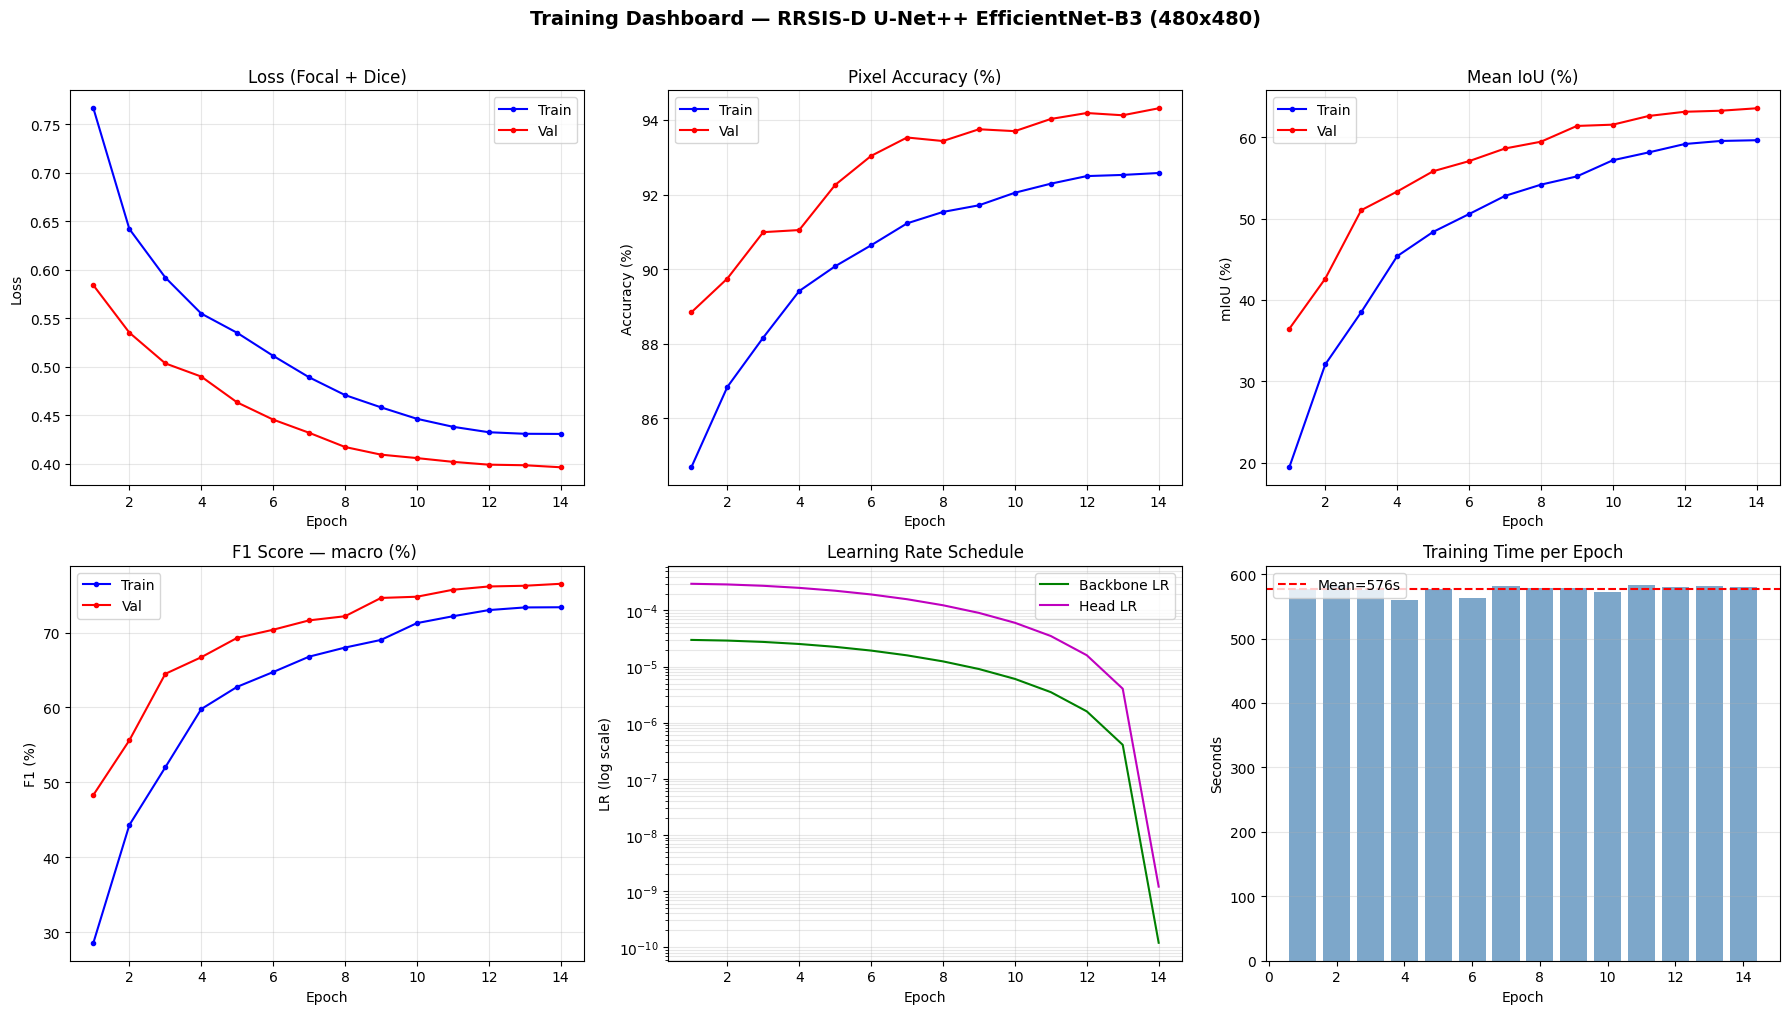

In [52]:
def plot_training_curves(history, save_path=None):
    """
    Plot 5-panel training dashboard:
      1. Loss (train + val)
      2. Pixel Accuracy (train + val)
      3. mIoU (train + val)
      4. F1 Score (train + val)
      5. Learning Rate (backbone + head)
    """
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Training Dashboard — RRSIS-D U-Net++ EfficientNet-B3 (480x480)',
                 fontsize=14, fontweight='bold', y=1.01)

    # ── 1. Loss ───────────────────────────────────────────────
    ax = axes[0, 0]
    ax.plot(epochs, history['train_loss'], 'b-o', ms=3, label='Train')
    ax.plot(epochs, history['val_loss'],   'r-o', ms=3, label='Val')
    ax.set_title('Loss (Focal + Dice)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(alpha=0.3)

    # ── 2. Pixel Accuracy ─────────────────────────────────────
    ax = axes[0, 1]
    ax.plot(epochs, [v * 100 for v in history['train_acc']], 'b-o', ms=3, label='Train')
    ax.plot(epochs, [v * 100 for v in history['val_acc']],   'r-o', ms=3, label='Val')
    ax.set_title('Pixel Accuracy (%)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
    ax.legend(); ax.grid(alpha=0.3)

    # ── 3. mIoU ───────────────────────────────────────────────
    ax = axes[0, 2]
    ax.plot(epochs, [v * 100 for v in history['train_miou']], 'b-o', ms=3, label='Train')
    ax.plot(epochs, [v * 100 for v in history['val_miou']],   'r-o', ms=3, label='Val')
    ax.set_title('Mean IoU (%)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('mIoU (%)')
    ax.legend(); ax.grid(alpha=0.3)

    # ── 4. F1 Score ───────────────────────────────────────────
    ax = axes[1, 0]
    ax.plot(epochs, [v * 100 for v in history['train_f1']], 'b-o', ms=3, label='Train')
    ax.plot(epochs, [v * 100 for v in history['val_f1']],   'r-o', ms=3, label='Val')
    ax.set_title('F1 Score — macro (%) ')
    ax.set_xlabel('Epoch'); ax.set_ylabel('F1 (%)')
    ax.legend(); ax.grid(alpha=0.3)

    # ── 5. Learning Rate ──────────────────────────────────────
    ax = axes[1, 1]
    ax.semilogy(epochs, history['lr_backbone'], 'g-', label='Backbone LR')
    ax.semilogy(epochs, history['lr_head'],     'm-', label='Head LR')
    ax.set_title('Learning Rate Schedule')
    ax.set_xlabel('Epoch'); ax.set_ylabel('LR (log scale)')
    ax.legend(); ax.grid(alpha=0.3, which='both')

    # ── 6. Epoch Time ─────────────────────────────────────────
    ax = axes[1, 2]
    ax.bar(epochs, history['epoch_time'], color='steelblue', alpha=0.7)
    ax.axhline(np.mean(history['epoch_time']), color='red',
               linestyle='--', label=f'Mean={np.mean(history["epoch_time"]):.0f}s')
    ax.set_title('Training Time per Epoch')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Seconds')
    ax.legend(); ax.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved to {save_path}')
    plt.show()


plot_training_curves(
    history,
    save_path=os.path.join(OUTPUT_DIR, 'training_curves.png')
)

## Test Set Evaluation - All Metrics

In [55]:
# Load best checkpoint
ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f'Loaded best checkpoint from epoch {ckpt["epoch"]}  '
      f'(val mIoU={ckpt["val_miou"]:.4f})\n')

test_stats = evaluate(model, test_loader, criterion, DEVICE)

print('=' * 55)
print(' TEST SET RESULTS')
print('=' * 55)
print(f'  Loss            : {test_stats["loss"]:.4f}')
print(f'  Pixel Accuracy  : {test_stats["pixel_acc"] * 100:.2f}%')
print(f'  Precision (mac) : {test_stats["precision"] * 100:.2f}%')
print(f'  Recall (macro)  : {test_stats["recall"] * 100:.2f}%')
print(f'  F1 (macro)      : {test_stats["f1"] * 100:.2f}%')
print(f'  mIoU            : {test_stats["mIoU"] * 100:.2f}%')
print(f'  oIoU            : {test_stats["oIoU"] * 100:.2f}%')
print(f'  Dice (mean)     : {test_stats["Dice"] * 100:.2f}%')
print('=' * 55)

print(f'\nModel info:')
print(f'  Total params      : {total_params:,}')
print(f'  Trainable params  : {trainable_params:,}')
print(f'  Model size        : {model_size_mb:.1f} MB')
print(f'  Epochs run        : {len(history["train_loss"])}')

print('\nPer-class IoU:')
print(f'  {"ID":<4} {"Class":<32} {"IoU":>6}')
print('  ' + '-' * 46)
iou_list = test_stats['iou_per_class']
for idx in range(NUM_LABELS):
    print(f'  {idx:<4} {id2label[idx]:<32} {iou_list[idx] * 100:>5.2f}%')

Loaded best checkpoint from epoch 14  (val mIoU=0.6355)



Eval :   0%|          | 0/327 [00:00<?, ?it/s]

 TEST SET RESULTS
  Loss            : 0.3891
  Pixel Accuracy  : 94.45%
  Precision (mac) : 75.03%
  Recall (macro)  : 80.39%
  F1 (macro)      : 76.93%
  mIoU            : 63.99%
  oIoU            : 89.48%
  Dice (mean)     : 76.93%

Model info:
  Total params      : 13,627,693
  Trainable params  : 13,627,693
  Model size        : 52.7 MB
  Epochs run        : 14

Per-class IoU:
  ID   Class                               IoU
  ----------------------------------------------
  0    background                       93.96%
  1    Expressway-Service-area          73.11%
  2    Expressway-toll-station          73.58%
  3    airplane                         69.74%
  4    airport                          65.92%
  5    baseballfield                    81.39%
  6    basketballcourt                  52.71%
  7    bridge                           48.84%
  8    chimney                          78.79%
  9    dam                              53.96%
  10   golffield                        67.83%
  1

## Confusion Matrix

Confusion matrix saved to /content/drive/MyDrive/CSE465/checkpoints/confusion_matrix.png


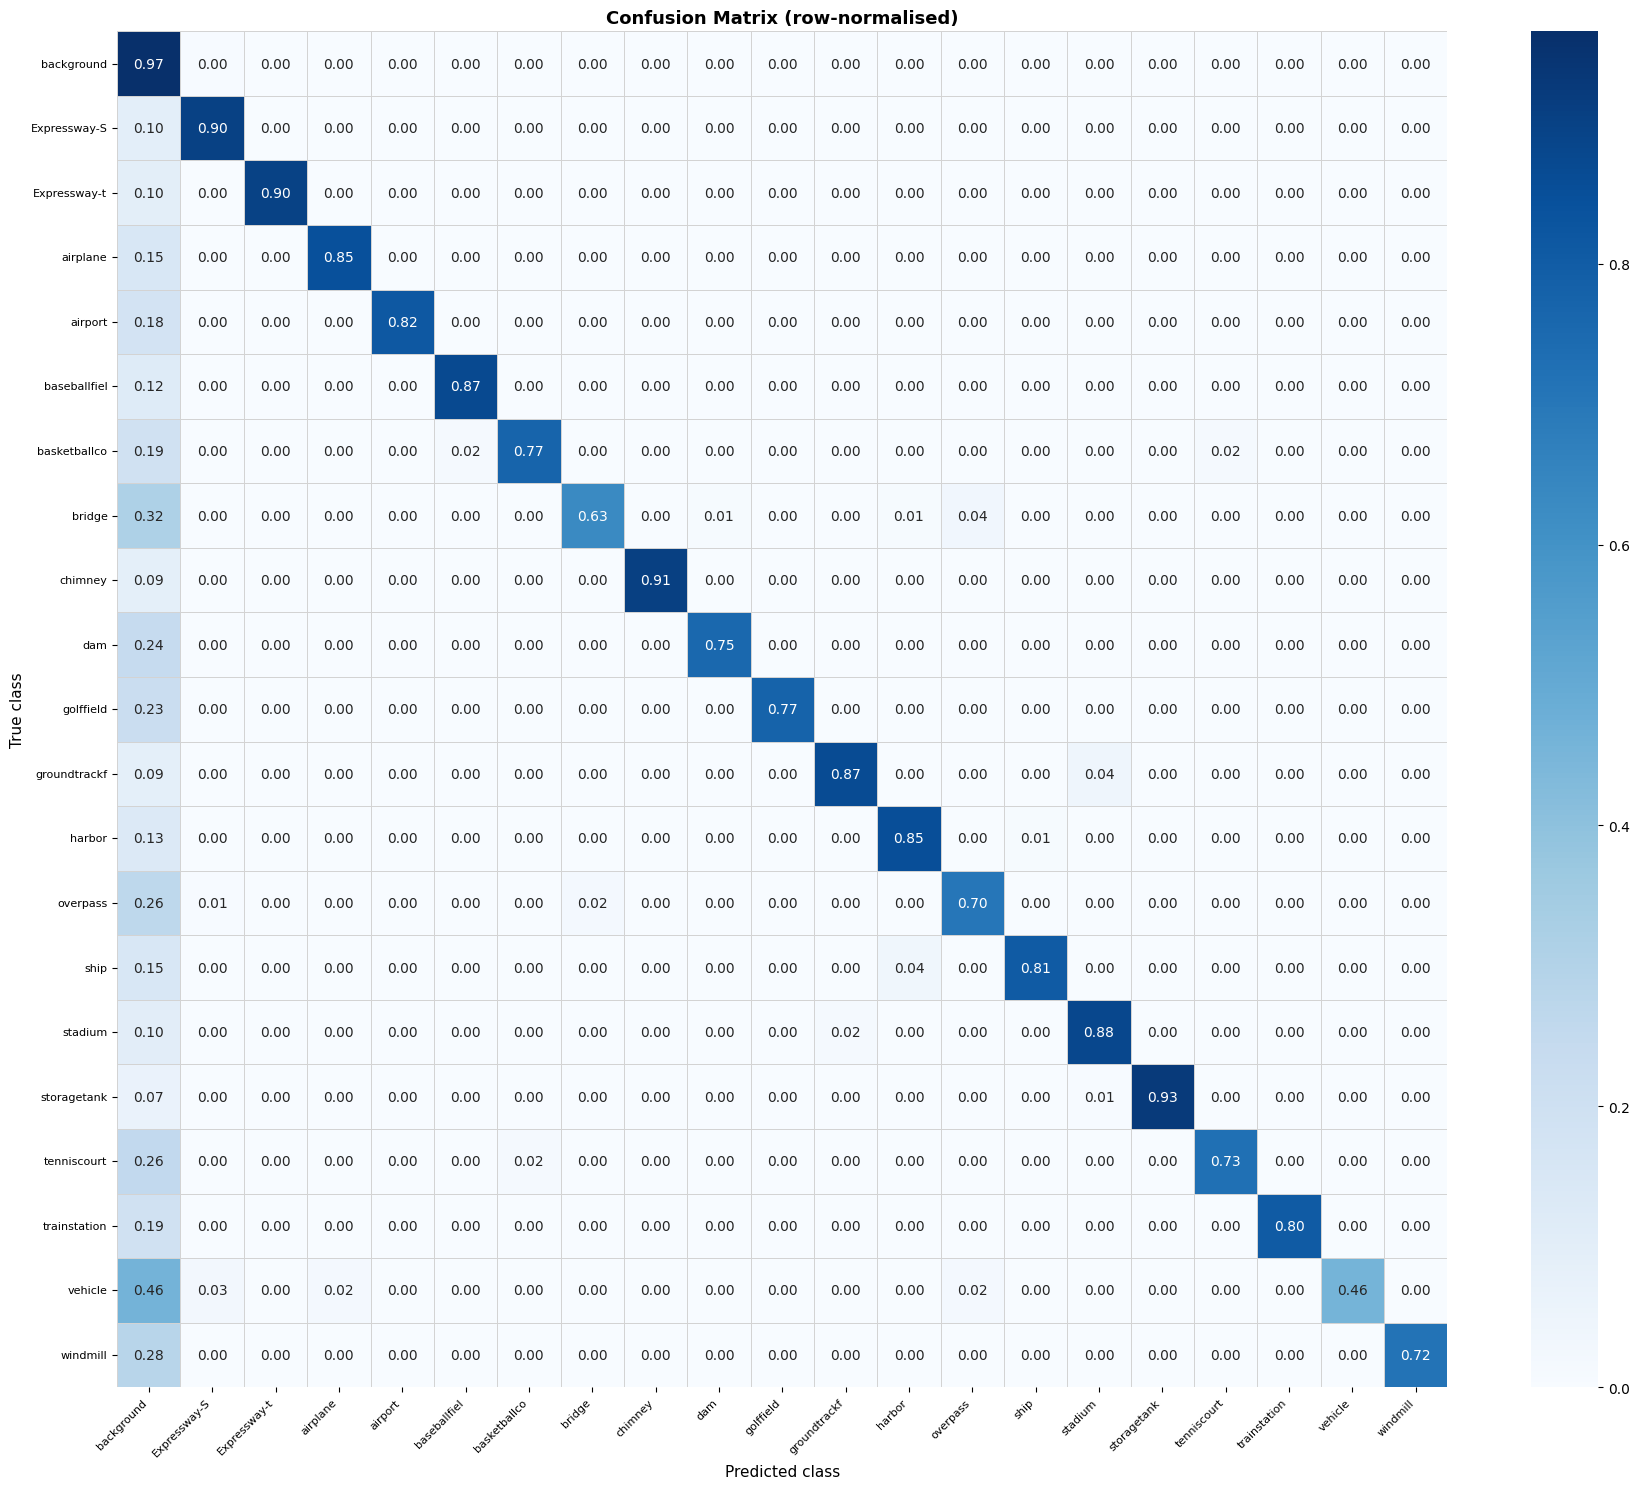

Confusion matrix saved to /content/drive/MyDrive/CSE465/checkpoints/confusion_matrix_raw.png


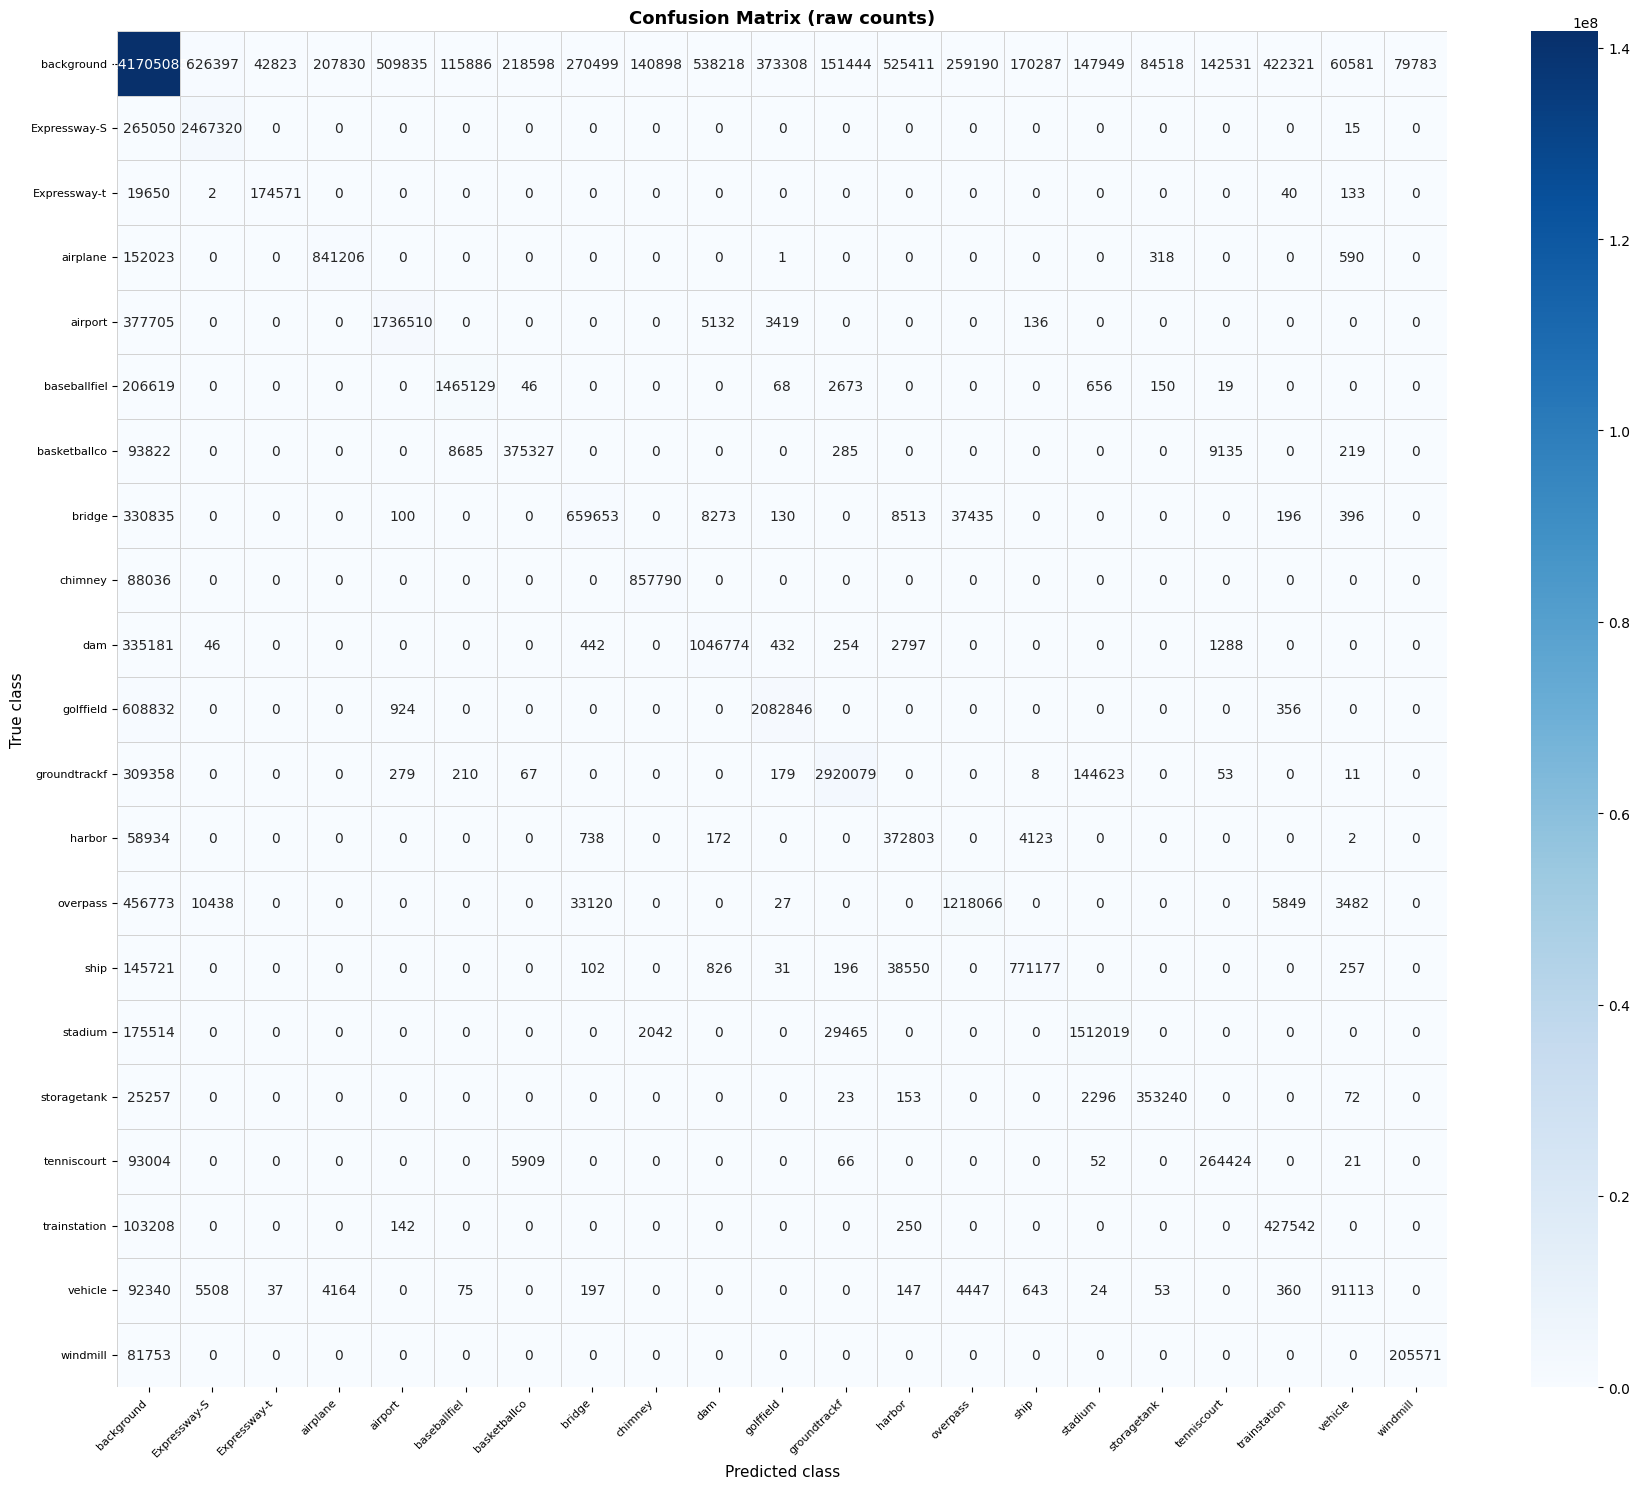

In [56]:
def plot_confusion_matrix(cm, labels, save_path=None, normalise=True):
    """
    Plot a seaborn heatmap of the confusion matrix.

    cm        : (NUM_LABELS, NUM_LABELS) numpy int array
    labels    : list of class names
    normalise : if True, show row-normalised percentages (recommended
                for imbalanced datasets — prevents large classes from
                dominating the colour scale)
    """
    if normalise:
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums = np.where(row_sums == 0, 1, row_sums)   # avoid divide-by-zero
        cm_plot  = cm.astype(float) / row_sums
        fmt      = '.2f'
        title    = 'Confusion Matrix (row-normalised)'
    else:
        cm_plot  = cm
        fmt      = 'd'
        title    = 'Confusion Matrix (raw counts)'

    short_labels = [l[:12] for l in labels]   # truncate long class names

    fig, ax = plt.subplots(figsize=(18, 15))
    sns.heatmap(
        cm_plot,
        annot=True, fmt=fmt, cmap='Blues',
        xticklabels=short_labels,
        yticklabels=short_labels,
        linewidths=0.4, linecolor='lightgrey',
        ax=ax
    )
    ax.set_xlabel('Predicted class', fontsize=11)
    ax.set_ylabel('True class',      fontsize=11)
    ax.set_title(title,              fontsize=13, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0,              fontsize=8)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Confusion matrix saved to {save_path}')
    plt.show()


# Plot normalised confusion matrix
plot_confusion_matrix(
    test_stats['_cm'],
    ALL_LABELS,
    save_path=os.path.join(OUTPUT_DIR, 'confusion_matrix.png'),
    normalise=True
)

# Plot raw-count confusion matrix (optional — comment out if too cluttered)
plot_confusion_matrix(
    test_stats['_cm'],
    ALL_LABELS,
    save_path=os.path.join(OUTPUT_DIR, 'confusion_matrix_raw.png'),
    normalise=False
)

## Per-Class Metrics Bar Chart

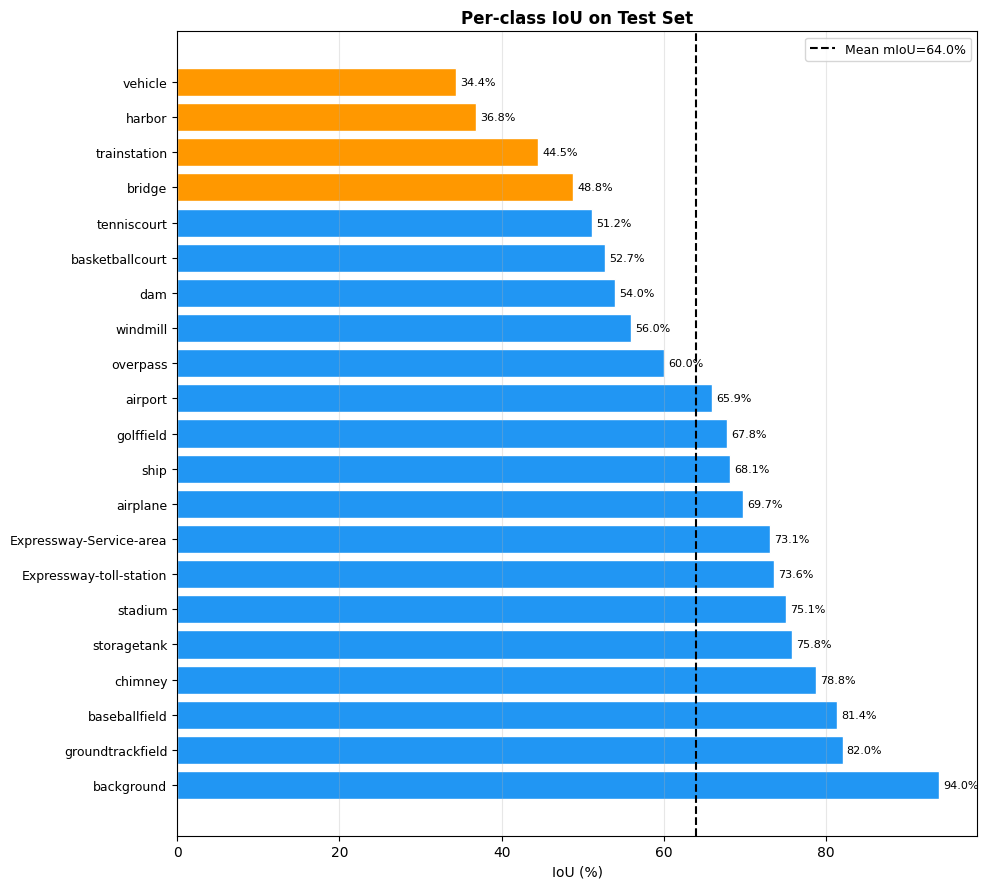

In [57]:
def plot_per_class_iou(iou_list, labels, save_path=None):
    """Horizontal bar chart of per-class IoU, sorted descending."""
    values = [iou_list[i] * 100 for i in range(len(labels))]
    pairs  = sorted(zip(labels, values), key=lambda x: x[1], reverse=True)
    names, vals = zip(*pairs)

    colours = ['#2196F3' if v >= 50 else '#FF9800' if v >= 25 else '#F44336'
               for v in vals]

    fig, ax = plt.subplots(figsize=(10, 9))
    bars = ax.barh(range(len(names)), vals, color=colours, edgecolor='white')
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel('IoU (%)')
    ax.set_title('Per-class IoU on Test Set', fontsize=12, fontweight='bold')
    ax.axvline(np.mean(vals), color='black', linestyle='--',
               label=f'Mean mIoU={np.mean(vals):.1f}%')
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.3)

    # Annotate bar values
    for bar, v in zip(bars, vals):
        ax.text(v + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{v:.1f}%', va='center', fontsize=8)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_per_class_iou(
    test_stats['iou_per_class'],
    ALL_LABELS,
    save_path=os.path.join(OUTPUT_DIR, 'per_class_iou.png')
)

## Qualitative Visualisation

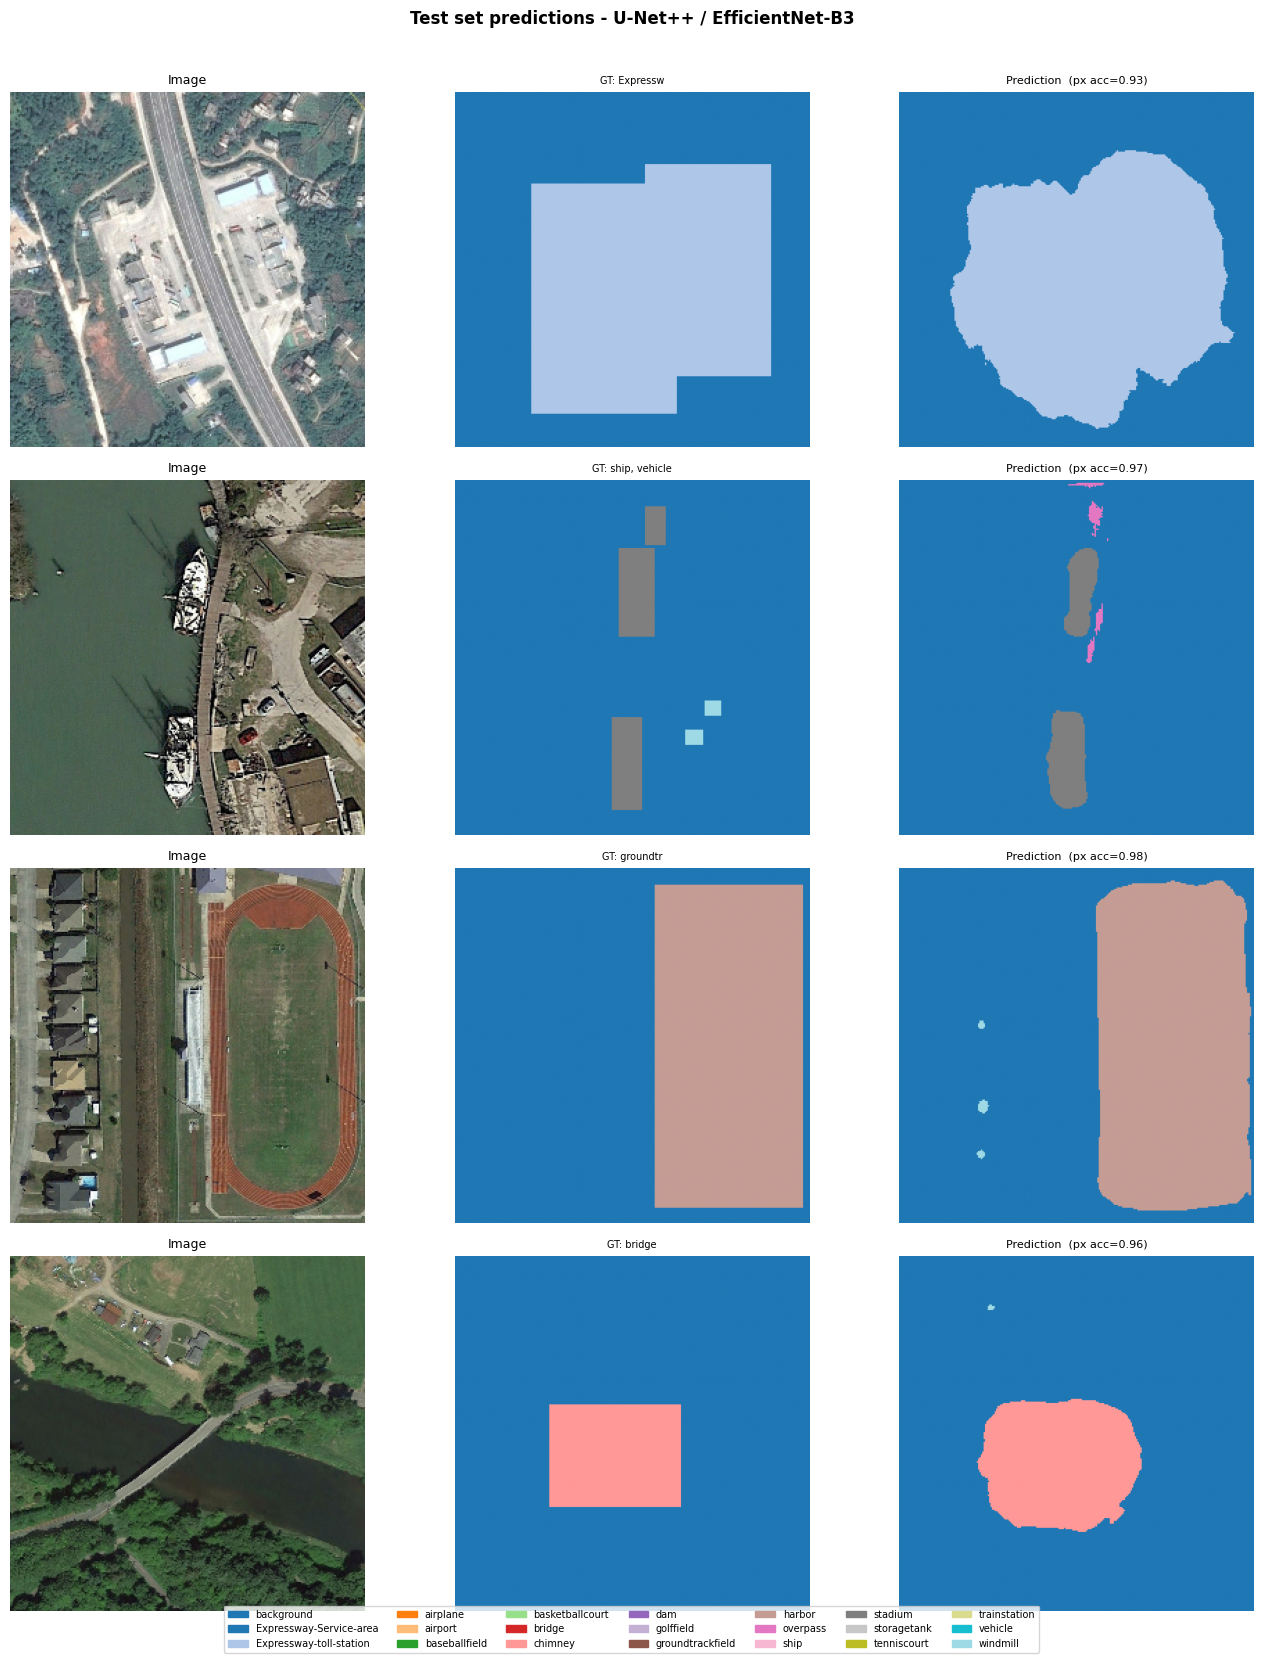

In [58]:
@torch.no_grad()
def visualise_predictions(model, dataset, n=4, device=DEVICE):
    """Display n test images with GT and predicted masks side-by-side."""
    model.eval()
    indices = random.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(n, 3, figsize=(14, 4 * n))
    if n == 1:
        axes = axes[np.newaxis]

    CMAP = plt.get_cmap('tab20')

    for row, idx in enumerate(indices):
        sample  = dataset[idx]
        img_t   = sample['pixel_values'].unsqueeze(0).to(device)
        gt_mask = sample['labels'].numpy()

        output = model(img_t)
        logits = output['out']
        if logits.shape[-2:] != gt_mask.shape:
            logits = F.interpolate(logits, size=gt_mask.shape,
                                   mode='bilinear', align_corners=False)
        pred_mask = logits.argmax(dim=1).squeeze().cpu().numpy()

        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_np = (sample['pixel_values'].cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        px_acc = float(np.mean(gt_mask == pred_mask))

        axes[row, 0].imshow(img_np)
        axes[row, 0].set_title('Image', fontsize=9); axes[row, 0].axis('off')

        axes[row, 1].imshow(gt_mask, cmap=CMAP, vmin=0, vmax=NUM_LABELS - 1)
        gt_classes = ', '.join(id2label[u][:8] for u in np.unique(gt_mask) if u > 0)[:40]
        axes[row, 1].set_title(f'GT: {gt_classes}', fontsize=7); axes[row, 1].axis('off')

        axes[row, 2].imshow(pred_mask, cmap=CMAP, vmin=0, vmax=NUM_LABELS - 1)
        axes[row, 2].set_title(f'Prediction  (px acc={px_acc:.2f})', fontsize=8)
        axes[row, 2].axis('off')

    patches = [mpatches.Patch(color=CMAP(i / NUM_LABELS), label=id2label[i])
               for i in range(NUM_LABELS)]
    fig.legend(handles=patches, loc='lower center', ncol=7,
               fontsize=7, bbox_to_anchor=(0.5, -0.02))
    plt.suptitle('Test set predictions - U-Net++ / EfficientNet-B3',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'test_predictions.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


visualise_predictions(model, test_ds, n=4)